# OCR: CTC с нуля — лосс, декодирование, метрики

Ноутбук к теме [`lesson.md`](lesson.md). «Объясните CTC» — вопрос, на который почти все отвечают словами; здесь мы вместо этого его **реализуем** и проверим каждое утверждение лекции прогоном.

1. Правило свёртки и вероятность строки — полным перебором путей
2. Forward-алгоритм — и сверка с перебором
3. CTC как лосс: обучаем логиты и смотрим, какое выравнивание выучилось
4. Жадное декодирование против prefix beam search
5. CER и WER: micro против macro

In [1]:
import itertools
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np

C_BG, C_INK, C_GRAY = "#faf9f5", "#141413", "#b0aea5"
C_PANEL, C_ORANGE, C_BLUE, C_GREEN = "#e8e6dc", "#d97757", "#6a9bcc", "#788c5d"
plt.rcParams.update({
    "figure.facecolor": C_BG, "axes.facecolor": C_BG, "axes.edgecolor": C_GRAY,
    "text.color": C_INK, "xtick.color": C_INK, "ytick.color": C_INK,
    "axes.labelcolor": C_INK, "font.size": 11, "legend.frameon": False,
})

BLANK = 0

## 1. Правило свёртки и вероятность строки перебором

Путь — выбор символа в каждом из $T$ столбцов; свёртка — схлопнуть повторы, выбросить blank. Вероятность строки — сумма по всем путям, которые в неё сворачиваются. Для игрушечного размера ($T=6$, алфавит из 4 символов) сумму можно посчитать в лоб — все $4^6 = 4096$ путей. Таблица вероятностей — та же, что на диаграмме в лекции.

In [2]:
def collapse(path):
    """Схлопнуть подряд идущие повторы, затем убрать blank."""
    out, prev = [], None
    for s in path:
        if s != prev and s != BLANK:
            out.append(s)
        prev = s
    return tuple(out)

SYMBOLS = ["–", "c", "a", "t"]
P_LESSON = np.array([
    #  –     c     a     t
    [0.10, 0.70, 0.10, 0.10],
    [0.15, 0.40, 0.35, 0.10],
    [0.20, 0.10, 0.60, 0.10],
    [0.35, 0.10, 0.35, 0.20],
    [0.25, 0.05, 0.05, 0.65],
    [0.60, 0.05, 0.05, 0.30],
])
TARGET = (1, 2, 3)  # «cat»

def brute_force(P, target):
    """Сумма по всем путям полным перебором."""
    T, V = P.shape
    total, paths = 0.0, []
    for path in itertools.product(range(V), repeat=T):
        if collapse(path) == tuple(target):
            p = float(np.prod(P[np.arange(T), path]))
            total += p
            paths.append((path, p))
    paths.sort(key=lambda x: -x[1])
    return total, paths

p_bf, paths = brute_force(P_LESSON, TARGET)
print(f"всего путей: {4**6}, из них сворачиваются в «cat»: {len(paths)}")
print(f"P(«cat») = {p_bf:.4f}")
print("топ-3 пути:")
for path, p in paths[:3]:
    print(f"  «{''.join(SYMBOLS[s] for s in path)}»  p = {p:.4f}")

всего путей: 4096, из них сворачиваются в «cat»: 84
P(«cat») = 0.2990
топ-3 пути:
  «cca–t–»  p = 0.0229
  «ccaat–»  p = 0.0229
  «caa–t–»  p = 0.0201


## 2. Forward-алгоритм — и сверка с перебором

Перебор экспоненциален, но сумма раскладывается динамикой по расширенной строке `– c – a – t –` (blank между буквами и по краям): $\alpha_t(i)$ — вероятность всех префиксов путей, которые к моменту $t$ «стоят» на позиции $i$. Это $O(T \cdot L)$ — как в HMM.

Сверим не на одном примере, а на пачке случайных таблиц и случайных целевых строк: реализация, которая совпала с перебором на 200 случайных задачах, скорее всего честная.

In [3]:
def ctc_forward(P, target):
    """P(target | P) суммой по путям — alpha-рекурсия."""
    ext = [BLANK]
    for s in target:
        ext += [s, BLANK]
    L = len(ext)
    alpha = np.zeros(L)
    alpha[0] = P[0][BLANK]
    if L > 1:
        alpha[1] = P[0][ext[1]]
    for t in range(1, len(P)):
        prev = alpha.copy()
        for i in range(L):
            a = prev[i]
            if i >= 1:
                a += prev[i - 1]
            if i >= 2 and ext[i] != BLANK and ext[i] != ext[i - 2]:
                a += prev[i - 2]
            alpha[i] = a * P[t][ext[i]]
    return alpha[-1] + (alpha[-2] if L > 1 else 0.0)

assert abs(ctc_forward(P_LESSON, TARGET) - p_bf) < 1e-12

rng = np.random.default_rng(0)
worst = 0.0
for _ in range(200):
    T, V = rng.integers(2, 7), rng.integers(2, 5)
    P = rng.dirichlet(np.ones(V), size=T)
    tgt = tuple(rng.integers(1, V, size=rng.integers(0, 4)))
    bf, _ = brute_force(P, tgt)
    worst = max(worst, abs(ctc_forward(P, tgt) - bf))
print(f"200 случайных задач: max |forward − перебор| = {worst:.2e}")

200 случайных задач: max |forward − перебор| = 1.11e-16


## 3. CTC как лосс: обучаем логиты и смотрим на выравнивание

Лосс — это $-\log P(y \mid x)$, и он дифференцируем по выходам сети. Устроим минимальный «тренинг»: вместо сети — просто матрица логитов $Z \in \mathbb{R}^{T \times V}$ (softmax по строкам даёт $P$), градиент считаем численно (для 48 параметров можно позволить), и учим её выдавать слово **«ванна»** при $T = 12$.

Слово выбрано не случайно: в нём двойная «н», и по лекции модель обязана поставить blank между повторами — иначе «нн» схлопнется. Заодно проверим утверждение о **пиковости**: после обучения почти вся вероятность строки должна сосредоточиться на одном-единственном пути.

In [4]:
SYM_W = ["–", "в", "а", "н"]
WORD = (1, 2, 3, 3, 2)  # «ванна»
T_W, V_W = 12, 4

def softmax(z):
    e = np.exp(z - z.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

def loss_of(z):
    return -np.log(ctc_forward(softmax(z), WORD))

rng = np.random.default_rng(7)
Z = 0.1 * rng.normal(size=(T_W, V_W))
P_before = softmax(Z)

lr, eps = 2.0, 1e-5
history = []
for _step in range(400):
    history.append(loss_of(Z))
    grad = np.zeros_like(Z)
    for i in range(T_W):
        for j in range(V_W):
            Z[i, j] += eps
            up = loss_of(Z)
            Z[i, j] -= 2 * eps
            dn = loss_of(Z)
            Z[i, j] += eps
            grad[i, j] = (up - dn) / (2 * eps)
    Z -= lr * grad
P_after = softmax(Z)

greedy = tuple(int(i) for i in P_after.argmax(axis=1))
path_str = "".join(SYM_W[s] for s in greedy)
word_str = "".join(SYM_W[s] for s in collapse(greedy))
p_word = np.exp(-history[-1])
p_path = float(np.prod(P_after[np.arange(T_W), greedy]))
print(f"лосс: {history[0]:.3f} → {history[-1]:.4f},  P(«ванна») = {p_word:.4f}")
print(f"жадный путь: «{path_str}» → «{word_str}»")
print(f"вероятность одного этого пути: {p_path:.4f} — {p_path / p_word:.0%} всей массы строки")
assert word_str == 'ванна'

лосс: 7.640 → 0.0086,  P(«ванна») = 0.9914
жадный путь: «вваанн––ннаа» → «ванна»
вероятность одного этого пути: 0.8870 — 89% всей массы строки


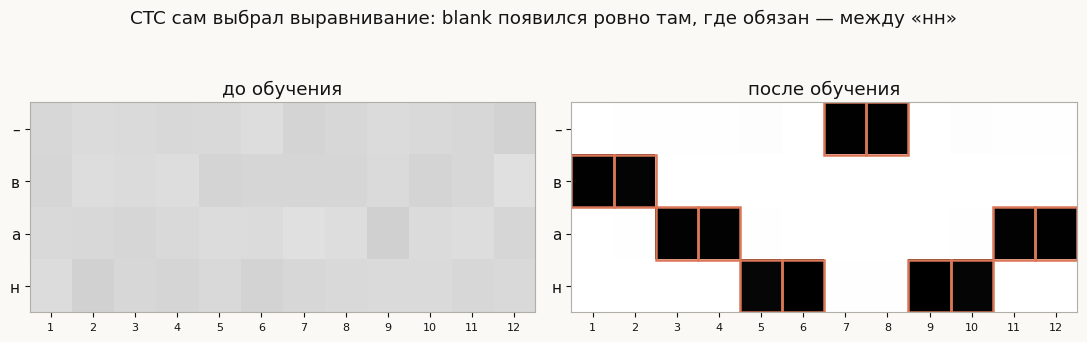

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for ax, M, title in [(axes[0], P_before, "до обучения"),
                     (axes[1], P_after, "после обучения")]:
    ax.imshow(M.T, cmap="Greys", vmin=0, vmax=1, aspect="auto")
    ax.set_yticks(range(V_W), SYM_W)
    ax.set_xticks(range(T_W), [str(t + 1) for t in range(T_W)], fontsize=8)
    ax.set_title(title)
for t, s in enumerate(P_after.argmax(axis=1)):
    axes[1].add_patch(plt.Rectangle((t - 0.5, s - 0.5), 1, 1, fill=False,
                                    edgecolor=C_ORANGE, lw=1.8))
fig.suptitle("CTC сам выбрал выравнивание: blank появился ровно там, где обязан — между «нн»",
             y=1.06)
plt.tight_layout()
plt.show()

Между двумя «н» в жадном пути стоит blank — без него слово было бы невозможно записать, и модель «поняла» это из одного лишь лосса. Пиковость тоже налицо: почти вся вероятность строки сидит на единственном пути, хотя сворачивающихся в «ванна» путей тысячи.

Любопытный честный нюанс: blank **не** захватил большинство столбцов. Модели ничто не мешает тянуть букву повторами («вваанн…») — повторы схлопываются так же бесплатно, как blank, и градиент здесь выбрал именно их. Доминирование blank, которое видят в настоящих OCR- и речевых моделях, — свойство обучения на реальных данных (столбцы между буквами на них ни на что не похожи), а не самого CTC-лосса.

## 4. Жадное декодирование против prefix beam search

Жадный ответ — свёртка argmax-пути — это самый вероятный **путь**, а не самая вероятная **строка**. Правильный поиск — beam search **по префиксам строк**: пути, сворачивающиеся в один префикс, сливаются, их вероятности складываются. Для каждого префикса храним две массы — «последний столбец был blank» и «последний столбец был буквой»: они по-разному продолжаются повтором буквы.

Реализуем и проверим на контрпримере из лекции, а потом — против полного перебора.

In [6]:
def greedy_decode(P):
    return collapse(tuple(int(i) for i in P.argmax(axis=1)))

def prefix_beam_search(P, k=25):
    """Возвращает [(строка, вероятность)] по убыванию. blank = 0."""
    beams = {(): (1.0, 0.0)}  # префикс -> (масса с blank на конце, с буквой)
    for t in range(len(P)):
        new = defaultdict(lambda: [0.0, 0.0])
        for prefix, (pb, pnb) in beams.items():
            for s, p in enumerate(P[t]):
                if s == BLANK:
                    new[prefix][0] += (pb + pnb) * p
                elif prefix and prefix[-1] == s:
                    new[prefix][1] += pnb * p              # повтор сливается
                    new[prefix + (s,)][1] += pb * p        # новая буква после blank
                else:
                    new[prefix + (s,)][1] += (pb + pnb) * p
        beams = dict(sorted(new.items(), key=lambda kv: -sum(kv[1]))[:k])
    return sorted(((pr, sum(m)) for pr, m in beams.items()), key=lambda x: -x[1])

# контрпример из лекции: T=2, алфавит {–, a}
P_toy = np.array([[0.6, 0.4], [0.6, 0.4]])
g = greedy_decode(P_toy)
beam = prefix_beam_search(P_toy)
print(f"жадное:      «{''.join('a' for _ in g) or '∅'}»")
for pr, p in beam[:2]:
    print(f"beam search: «{'a' * len(pr) or '∅'}»  P = {p:.2f}")

# сверка с перебором: маргиналы всех строк на случайной таблице
rng = np.random.default_rng(1)
P_rand = rng.dirichlet(np.ones(3), size=4)
marg = defaultdict(float)
for path in itertools.product(range(3), repeat=4):
    marg[collapse(path)] += float(np.prod(P_rand[np.arange(4), path]))
beam_full = dict(prefix_beam_search(P_rand, k=10_000))
worst = max(abs(marg[s] - beam_full[s]) for s in marg)
print(f"\nполный beam против перебора: max расхождение = {worst:.2e}")

жадное:      «∅»
beam search: «a»  P = 0.64
beam search: «∅»  P = 0.36

полный beam против перебора: max расхождение = 2.78e-17


In [7]:
def disagreement_rate(alpha, trials=300, T=5, V=4, seed=2):
    """Как часто жадное и beam search дают разные строки.

    alpha — острота Дирихле: маленькая -> пиковые столбцы, большая -> размытые.
    """
    rng = np.random.default_rng(seed)
    diff = 0
    for _ in range(trials):
        P = rng.dirichlet(np.full(V, alpha), size=T)
        if greedy_decode(P) != prefix_beam_search(P, k=200)[0][0]:
            diff += 1
    return diff / trials

for alpha in (3.0, 0.3, 0.03):
    r = disagreement_rate(alpha)
    print(f"alpha = {alpha:>4}: жадное ≠ beam в {r:.0%} случаев")

g_tr, b_tr = greedy_decode(P_after), prefix_beam_search(P_after, k=200)[0][0]
print(f"\nна обученной пиковой таблице из раздела 3: жадное {'==' if g_tr == b_tr else '!='} beam")

alpha =  3.0: жадное ≠ beam в 74% случаев


alpha =  0.3: жадное ≠ beam в 28% случаев


alpha = 0.03: жадное ≠ beam в 1% случаев

на обученной пиковой таблице из раздела 3: жадное == beam


Тренд монотонный: чем острее столбцы, тем реже жадный ответ расходится с самой вероятной строкой, а на по-настоящему обученной (и потому пиковой) таблице из раздела 3 они совпадают. Случайные Дирихле-таблицы — это худший случай, которого обученная модель почти не встречает; но именно на трудных, размытых участках (шум, низкий контраст) beam search с языковой моделью и отрабатывает свой хлеб.

## 5. CER и WER: micro против macro

Качество OCR меряют расстоянием Левенштейна, нормированным на длину эталона: посимвольно (CER) или пословно (WER). Помимо контраста CER/WER из лекции проверим две ловушки: **CER больше единицы** при галлюцинации и расхождение **micro / macro** усреднения по корпусу.

In [8]:
def levenshtein(a, b):
    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        cur = [i]
        for j, cb in enumerate(b, 1):
            cur.append(min(prev[j] + 1, cur[-1] + 1, prev[j - 1] + (ca != cb)))
        prev = cur
    return prev[-1]

def cer(ref, hyp):
    return levenshtein(ref, hyp) / len(ref)

def wer(ref, hyp):
    return levenshtein(ref.split(), hyp.split()) / len(ref.split())

ref, hyp = "модель читает текст", "модел чнтает тексt"
print(f"«{ref}» → «{hyp}»")
print(f"  расстояние = {levenshtein(ref, hyp)},  CER = {cer(ref, hyp):.3f},  WER = {wer(ref, hyp):.3f}")

ref2, hyp2 = "ок", "оказалось нет"
print(f"\nгаллюцинация: «{ref2}» → «{hyp2}»:  CER = {cer(ref2, hyp2):.1f}  (больше 1!)")

refs = ["распознавание текста", "ок"]
hyps = ["распознование текста", "по"]
macro = np.mean([cer(r, h) for r, h in zip(refs, hyps)])
micro = sum(levenshtein(r, h) for r, h in zip(refs, hyps)) / sum(len(r) for r in refs)
print("\nкорпус из длинной строки (1 ошибка) и короткой (2 ошибки):")
print(f"  macro-CER (среднее по строкам)      = {macro:.3f}")
print(f"  micro-CER (сумма дист. / сумма длин) = {micro:.3f}")

«модель читает текст» → «модел чнтает тексt»
  расстояние = 3,  CER = 0.158,  WER = 1.000

галлюцинация: «ок» → «оказалось нет»:  CER = 5.5  (больше 1!)

корпус из длинной строки (1 ошибка) и короткой (2 ошибки):
  macro-CER (среднее по строкам)      = 0.525
  micro-CER (сумма дист. / сумма длин) = 0.136


Три посимвольные ошибки дают CER 0.16 при WER 1.00 — метрики отвечают на разные вопросы. CER 5.5 у галлюцинации напоминает, что это нормированное расстояние, а не «процент ошибок». А macro-CER вчетверо выше micro-CER на том же корпусе: короткая строка с двумя ошибками весит в macro столько же, сколько длинная, — сравнивать числа можно только зная способ усреднения.

**Итог прогона.** Forward-алгоритм совпал с перебором на 200 случайных задачах; обучение CTC-лоссом само нашло выравнивание, поставило blank между «нн» и ушло в пиковый режим; beam search по префиксам сошёлся с точными маргиналами и разошёлся с жадным ровно там, где распределения размыты; CER и WER посчитаны одной и той же динамикой на разных единицах.